# What Drives Market Value? (Analysis)

This notebook looks for the stats behind player prices. Each section answers one question using the Postgres database built in the earlier steps:

- How are prices spread out?
- How does age affect price?
- Do players who play more cost more?
- Do goals and expected goals (xG) raise prices?
- Do different positions price differently?
- Which stats should the price model use?

Per-90 numbers only cover players with 500+ minutes. Small samples mislead (a brace in 10 minutes is not a scoring rate).

## Cell 1 — Database connection and scope check

Connects to Postgres (password prompt; nothing is stored) and defines `q()`, a helper that runs SQL and returns a table. The scope query counts rows and seasons and shows the cheapest vs most expensive player, matching the join and feature notebooks.

In [1]:
import getpass
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg2

pwd = getpass.getpass('postgres password: ')
conn = psycopg2.connect(host='localhost', dbname='fri', user='postgres', password=pwd)

def q(sql):
    return pd.read_sql(sql, conn)

print(q('SELECT count(*) AS rows, count(DISTINCT league_season) AS seasons, '
        'min(market_value_in_eur) AS min_v, max(market_value_in_eur) AS max_v '
        'FROM player_season WHERE market_value_in_eur IS NOT NULL').to_string())


   rows  seasons  min_v      max_v
0  6400       23  25000  180000000


C:\Users\User\AppData\Local\Temp\ipykernel_2304\888413080.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


## Cell 2 — Price spread (why the model predicts log-price)

Two charts. Raw prices pile near zero with a few superstars far right (median ~€3M, max €180M); a model on raw euros would serve only the superstars. Log-prices form a learnable shape instead. Conclusion: the model predicts log-price, converted back to euros afterwards.

C:\Users\User\AppData\Local\Temp\ipykernel_2304\888413080.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


count    6400.000
mean       15.109
std         1.363
min        10.127
25%        14.221
50%        14.979
75%        16.118
max        19.008


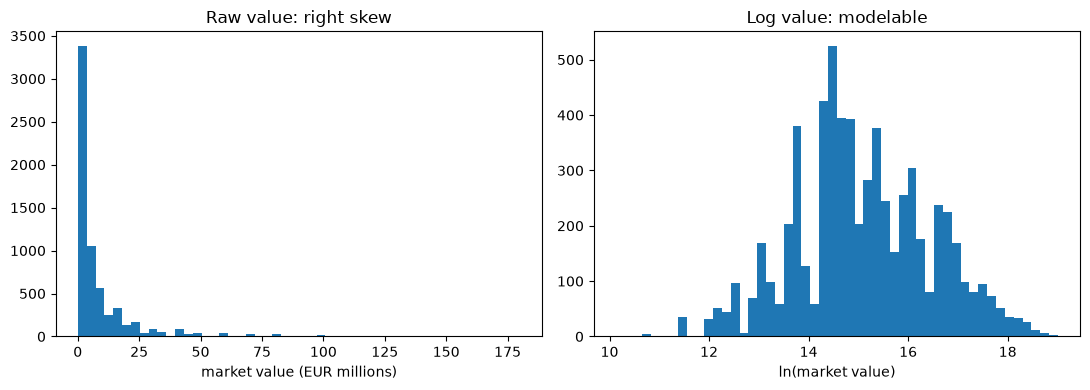

In [2]:
v = q('SELECT market_value_in_eur AS v FROM player_season WHERE market_value_in_eur > 0')
v['ln_v'] = np.log(v['v'])
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(v['v'] / 1e6, bins=50)
ax[0].set_xlabel('market value (EUR millions)')
ax[0].set_title('Raw value: right skew')
ax[1].hist(v['ln_v'], bins=50)
ax[1].set_xlabel('ln(market value)')
ax[1].set_title('Log value: modelable')
plt.tight_layout()
print(v['ln_v'].describe().round(3).to_string())


## Cell 3 — The age curve

Median log-price per age year. Prices rise, peak mid-to-late 20s, then fall — a curve, not a line — so the model uses age plus age-squared (the standard way to fit curves). Sparse ages at the tails are noise.

C:\Users\User\AppData\Local\Temp\ipykernel_2304\888413080.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


    age     med_ln    n
0    17  13.762830   18
1    18  14.038654   71
2    19  14.220976  171
3    20  14.731801  265
4    21  15.201805  325
5    22  15.201805  412
6    23  15.319588  475
7    24  15.424948  497
8    25  15.319588  533
9    26  15.201805  546
10   27  15.319588  555
11   28  15.201805  508
12   29  15.201805  442
13   30  15.068274  412
14   31  14.845130  357
15   32  14.508658  298
16   33  14.151983  173
17   34  13.710150  135
18   35  13.304685   88
19   36  13.122363   50
20   37  12.611538   24
21   38  13.122363   27
22   39  12.866951   10
23   40  12.317644    4


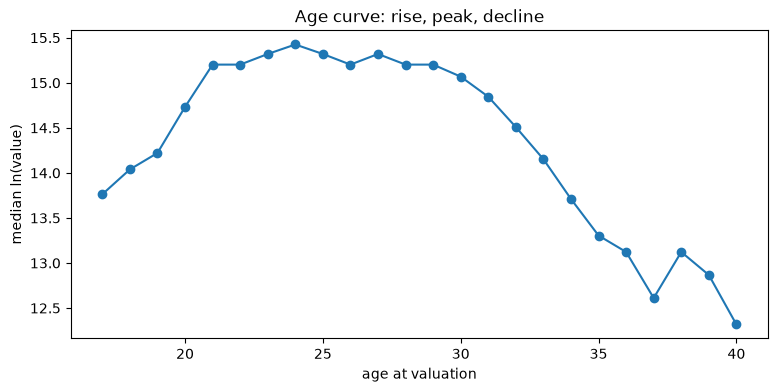

In [3]:
age = q('SELECT EXTRACT(YEAR FROM AGE(ps.value_date, p.date_of_birth))::int AS age, '
        'percentile_cont(0.5) WITHIN GROUP (ORDER BY LN(ps.market_value_in_eur)) AS med_ln, '
        'count(*) AS n '
        'FROM player_season ps JOIN players p USING (player_id) '
        'WHERE ps.market_value_in_eur > 0 AND p.date_of_birth IS NOT NULL '
        'GROUP BY 1 ORDER BY 1')
age = age[(age['age'] >= 16) & (age['age'] <= 40)]
plt.figure(figsize=(9, 4))
plt.plot(age['age'], age['med_ln'], marker='o')
plt.xlabel('age at valuation')
plt.ylabel('median ln(value)')
plt.title('Age curve: rise, peak, decline')
print(age.to_string())


## Cell 4 — Playing time vs price

Regulars cost more than fringe players. The lasting output is the 500-minute cutoff applied to every rate analysis that follows: the bands table shows it keeps ~1,000 player-seasons while cutting the noisy tail.

        band     n     med_ln
0      0-500  5423  14.914123
1   500-1000   488  15.319588
2  1000-2000   452  15.607270
3      2000+    37  15.424948


C:\Users\User\AppData\Local\Temp\ipykernel_2304\888413080.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


Text(0.5, 1.0, 'Regulars are worth more than fringe')

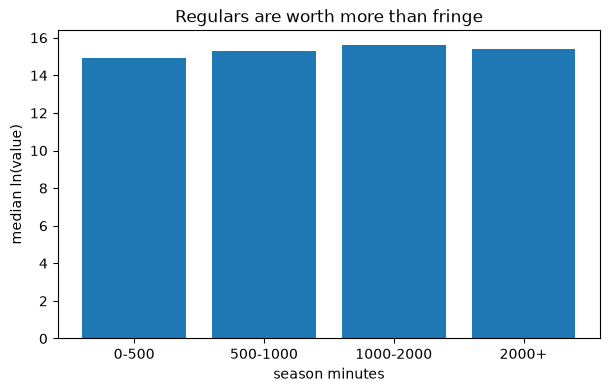

In [4]:
bands = q('SELECT CASE WHEN minutes < 500 THEN \'0-500\' WHEN minutes < 1000 THEN \'500-1000\' '
          'WHEN minutes < 2000 THEN \'1000-2000\' ELSE \'2000+\' END AS band, '
          'count(*) AS n, percentile_cont(0.5) WITHIN GROUP '
          '(ORDER BY LN(market_value_in_eur)) AS med_ln '
          'FROM player_season WHERE market_value_in_eur > 0 '
          'GROUP BY 1 ORDER BY min(minutes)')
print(bands.to_string())
plt.figure(figsize=(7, 4))
plt.bar(bands['band'], bands['med_ln'])
plt.xlabel('season minutes')
plt.ylabel('median ln(value)')
plt.title('Regulars are worth more than fringe')


## Cell 5 — Goals and xG vs price (attackers)

Two scatter plots over high-minute attackers; both slope upward. xG carries more weight in the reading: it measures chance quality (repeatable skill), while goals blend skill with finishing luck. The correlation table puts numbers on both.

C:\Users\User\AppData\Local\Temp\ipykernel_2304\888413080.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


           goals_p90  xg_p90  shots_p90   ln_v
goals_p90      1.000   0.942      0.917  0.505
xg_p90         0.942   1.000      0.939  0.491
shots_p90      0.917   0.939      1.000  0.499
ln_v           0.505   0.491      0.499  1.000


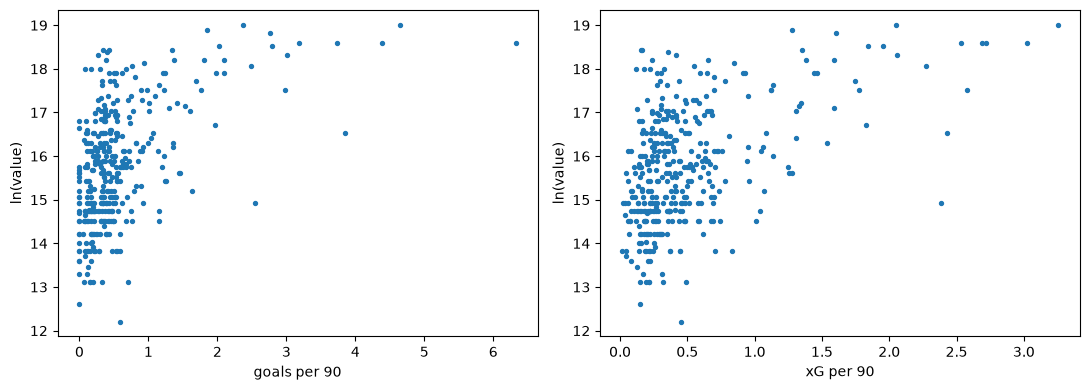

In [5]:
att = q("SELECT goals_p90, xg_p90, shots_p90, LN(market_value_in_eur) AS ln_v FROM player_season "
        "WHERE minutes >= 500 AND market_value_in_eur > 0 AND "
        "(position LIKE '%Forward%' OR position LIKE '%Wing%' OR position LIKE '%Striker%')")
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(att['goals_p90'], att['ln_v'], s=8)
ax[0].set_xlabel('goals per 90')
ax[0].set_ylabel('ln(value)')
ax[1].scatter(att['xg_p90'], att['ln_v'], s=8)
ax[1].set_xlabel('xG per 90')
ax[1].set_ylabel('ln(value)')
plt.tight_layout()
print(att[['goals_p90', 'xg_p90', 'shots_p90', 'ln_v']].corr().round(3).to_string())


## Cell 6 — Positions price differently

Median price and signature stats per position group. Defenders trail on attacking numbers by definition, so each group is read on its own terms — duels and interceptions for defenders, passing and carrying for midfielders. Modeling consequence: position enters as group labels, and defensive stats count within-group.

In [6]:
pos = q('SELECT CASE WHEN position LIKE \'%Goalkeeper%\' THEN \'GK\' '
          'WHEN position LIKE \'%Forward%\' OR position LIKE \'%Wing%\' OR position LIKE \'%Striker%\' THEN \'Attack\' '
          'WHEN position LIKE \'%Midfield%\' THEN \'Midfield\' '
          'WHEN position LIKE \'%Back%\' THEN \'Defence\' ELSE \'Other\' END AS grp, '
          'count(*) AS n, percentile_cont(0.5) WITHIN GROUP (ORDER BY market_value_in_eur) AS med_v, '
          'AVG(goals_p90) AS g90, AVG(xg_p90) AS xg90, AVG(passes_p90) AS p90, '
          'AVG(carries_p90) AS c90, AVG(duels_w_p90) AS dw90, AVG(interceptions_p90) AS int90 '
          'FROM player_season WHERE minutes >= 500 AND market_value_in_eur > 0 '
          'GROUP BY 1 ORDER BY med_v DESC')
print(pos.round(3).to_string())


        grp    n      med_v    g90   xg90      p90      c90   dw90  int90
0    Attack  377  6500000.0  0.559  0.501   57.014   54.202  1.093  0.892
1  Midfield  425  5000000.0  0.161  0.161   93.798   76.353  2.586  2.215
2   Defence  175  3500000.0  0.117  0.111  153.708  106.795  3.328  4.221


C:\Users\User\AppData\Local\Temp\ipykernel_2304\888413080.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


## Cell 7 — Correlation table and feature shortlist

Every candidate stat against log-price, strongest first. Around 0.4 for attacking and progression stats is strong for football data and confirms the list. Near-zero defensive readings reflect position-mixing (defenders defend and cost less), not uselessness. Age near zero hides the Cell 3 curve from a straight-line measure; age still enters as age plus age-squared. The printed shortlist feeds the price model.

In [7]:
feat = q('SELECT minutes, matches, starts, passes_p90, pass_pct, drib_ok_p90, carries_p90, '
         'pressures_p90, duels_w_p90, interceptions_p90, recoveries_p90, clearances_p90, '
         'shots_p90, goals_p90, xg_p90, LN(market_value_in_eur) AS ln_v, '
         'EXTRACT(YEAR FROM AGE(value_date, (SELECT date_of_birth FROM players p '
         'WHERE p.player_id = player_season.player_id))) AS age '
         'FROM player_season WHERE minutes >= 500 AND market_value_in_eur > 0')
print(feat.corr(numeric_only=True)['ln_v'].drop('ln_v').round(3).sort_values(ascending=False).to_string())
print()
print('SHORTLIST: minutes, age, age^2, goals_p90, xg_p90, shots_p90, passes_p90, pass_pct, '
      'drib_ok_p90, carries_p90, pressures_p90, duels_w_p90, interceptions_p90, '
      'recoveries_p90, position-group dummies, league dummies. Target: ln(value).')


carries_p90          0.389
drib_ok_p90          0.388
goals_p90            0.380
pass_pct             0.379
xg_p90               0.375
shots_p90            0.370
passes_p90           0.256
starts               0.125
minutes              0.116
recoveries_p90       0.055
matches              0.051
duels_w_p90         -0.009
pressures_p90       -0.039
interceptions_p90   -0.067
clearances_p90      -0.148
age                 -0.163

SHORTLIST: minutes, age, age^2, goals_p90, xg_p90, shots_p90, passes_p90, pass_pct, drib_ok_p90, carries_p90, pressures_p90, duels_w_p90, interceptions_p90, recoveries_p90, position-group dummies, league dummies. Target: ln(value).


C:\Users\User\AppData\Local\Temp\ipykernel_2304\888413080.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


## Next steps

1. Cross-check the shortlist with Cells 2–6 (no surprise signs, no single dominant stat).
2. Train baseline, Linear Regression, Random Forest, and XGBoost; compare MAE, RMSE, R².
3. Explain the winner with SHAP; flag undervalued players from predicted vs actual.